In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.2 KB


In [5]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [6]:
df.shape

(200, 2)

In [7]:
df.isnull().sum()

cgpa       0
package    0
dtype: int64

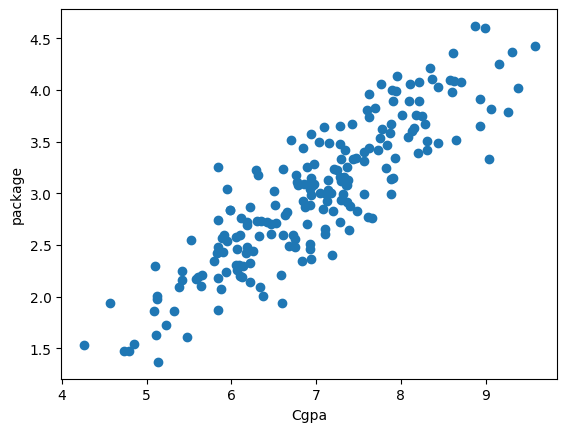

In [8]:
plt.scatter(df['cgpa'] , df['package'])
plt.xlabel("Cgpa")
plt.ylabel("package")
plt.show()

In [9]:
x = df[['cgpa']]
y = df['package']

In [10]:
x

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [11]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [12]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

In [17]:
X_train.head()

,cgpa
79,7.18
197,7.21
38,8.62
24,6.53
122,5.12


In [18]:
y_train

79     3.00
197    3.24
38     4.36
24     2.71
122    2.01
       ... 
106    2.19
14     3.42
92     4.00
179    3.03
102    1.37
Name: package, Length: 160, dtype: float64

In [19]:
X_test.head()

,cgpa
95,6.63
15,7.25
30,7.36
158,5.95
128,7.93


In [20]:
y_test

95     2.79
15     3.23
30     3.26
158    3.04
128    3.34
115    4.21
69     2.94
170    2.87
174    2.99
45     3.58
66     1.63
182    2.08
165    4.08
78     2.21
186    3.47
177    3.64
56     2.74
152    3.08
82     2.17
68     2.99
124    2.31
16     2.35
148    3.40
93     3.08
65     3.81
60     2.19
84     1.53
67     2.89
125    3.16
132    2.48
9      3.51
18     2.98
55     3.39
75     3.28
150    2.73
104    3.74
135    2.60
137    3.13
164    3.82
76     3.15
Name: package, dtype: float64

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
model = LinearRegression()

In [15]:
model.fit(X_train , y_train)

LinearRegression()

In [21]:
pred = model.predict(X_test)

In [22]:
pred

array([2.78031348, 3.13635249, 3.1995207 , 2.38981908, 3.52684689,
       3.76803461, 3.16506531, 2.54486832, 3.17655044, 3.4923915 ,
       1.90744364, 2.34962112, 3.6876387 , 2.75734322, 3.47516381,
       3.04447145, 2.32665086, 3.20526327, 2.17734418, 3.314372  ,
       2.45298729, 2.90090734, 3.32011456, 2.87219451, 3.33734226,
       2.19457187, 1.41932564, 2.7114027 , 3.18229301, 2.32665086,
       3.74506435, 2.95833298, 3.68189614, 2.97556068, 2.59080884,
       3.34882738, 2.47595755, 3.07318428, 4.17575671, 2.95833298])

In [25]:
model.predict(X_test.iloc[0].values.reshape(1,1))

C:\Users\vedus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.78031348])

In [29]:
from sklearn.metrics import r2_score

In [30]:
print(r2_score(pred , y_test))

0.733797338294438


In [31]:
m = model.coef_
m

array([0.57425647])

In [32]:
c = model.intercept_
c

-1.0270069374542108

In [33]:
# y = mx + c

y = 0.57425647 * 6.63 - 1.0270069374542108

In [34]:
y

2.7803134586457894

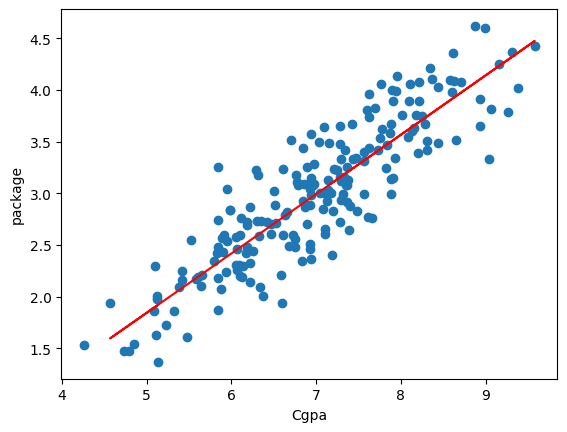

In [37]:
plt.scatter(df['cgpa'] , df['package'])
plt.plot(X_train , model.predict(X_train) , color = "red")
plt.xlabel("Cgpa")
plt.ylabel("package")
plt.show()